<a href="https://colab.research.google.com/github/AJAXSINGH/DAA-PROJECT/blob/main/DAA5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Array : [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]
Minimum : 0
Maximum : 9

Divide & Conquer Comparisons : 14
Naive Comparisons            : 18


    Size         DC        Naive     3n/2 - 2
---------------------------------------------
      10         14           18           13
     100        162          198          148
    1000       1510         1998         1498
   10000      15902        19998        14998


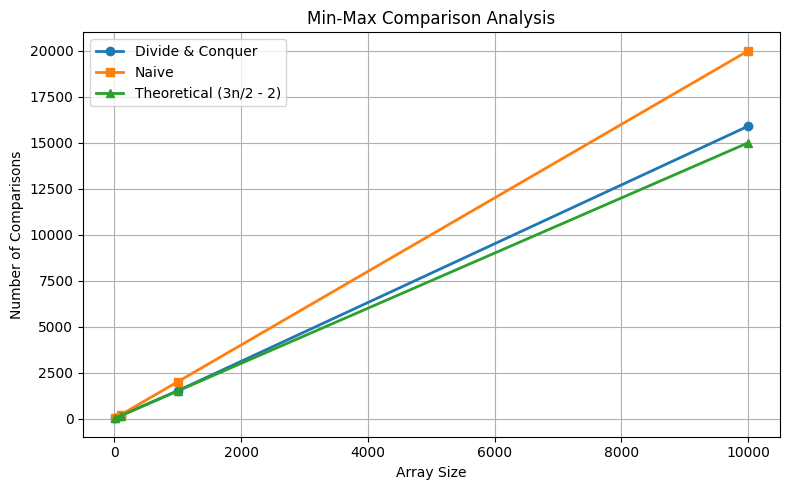

In [1]:
import random
import matplotlib.pyplot as plt

# Global comparison counter
comparison_count = 0


# ---------------- DIVIDE & CONQUER ----------------

def min_max_dc(arr, low, high):
    global comparison_count

    # Base case: one element
    if low == high:
        return arr[low], arr[low]

    # Base case: two elements
    if high == low + 1:
        comparison_count += 1

        if arr[low] < arr[high]:
            return arr[low], arr[high]
        else:
            return arr[high], arr[low]

    # Divide
    mid = (low + high) // 2

    left_min, left_max = min_max_dc(arr, low, mid)
    right_min, right_max = min_max_dc(arr, mid + 1, high)

    # Combine
    comparison_count += 1
    overall_min = left_min if left_min < right_min else right_min

    comparison_count += 1
    overall_max = left_max if left_max > right_max else right_max

    return overall_min, overall_max


# ---------------- NAIVE METHOD ----------------

def min_max_naive(arr):

    minimum = arr[0]
    maximum = arr[0]

    comparisons = 0

    for value in arr[1:]:

        comparisons += 1
        if value < minimum:
            minimum = value

        comparisons += 1
        if value > maximum:
            maximum = value

    return minimum, maximum, comparisons


# ---------------- DEMONSTRATION ----------------

arr = [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]

comparison_count = 0

minimum, maximum = min_max_dc(arr, 0, len(arr) - 1)
dc_comparisons = comparison_count

_, _, naive_comparisons = min_max_naive(arr)

print("Array :", arr)
print("Minimum :", minimum)
print("Maximum :", maximum)

print("\nDivide & Conquer Comparisons :", dc_comparisons)
print("Naive Comparisons            :", naive_comparisons)


# ---------------- PERFORMANCE ANALYSIS ----------------

sizes = [10, 100, 1000, 10000]

dc_values = []
naive_values = []
formula_values = []

print("\n")
print(f"{'Size':>8} {'DC':>10} {'Naive':>12} {'3n/2 - 2':>12}")
print("-" * 45)

for size in sizes:

    arr = [random.randint(1, 100000) for _ in range(size)]

    comparison_count = 0

    minimum, maximum = min_max_dc(arr, 0, len(arr) - 1)

    dc = comparison_count

    _, _, naive = min_max_naive(arr)

    formula = (3 * size) // 2 - 2

    dc_values.append(dc)
    naive_values.append(naive)
    formula_values.append(formula)

    print(f"{size:>8} {dc:>10} {naive:>12} {formula:>12}")


# ---------------- GRAPH ----------------

plt.figure(figsize=(8, 5))

plt.plot(
    sizes,
    dc_values,
    marker='o',
    linewidth=2,
    label='Divide & Conquer'
)

plt.plot(
    sizes,
    naive_values,
    marker='s',
    linewidth=2,
    label='Naive'
)

plt.plot(
    sizes,
    formula_values,
    marker='^',
    linewidth=2,
    label='Theoretical (3n/2 - 2)'
)

plt.title("Min-Max Comparison Analysis")
plt.xlabel("Array Size")
plt.ylabel("Number of Comparisons")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()